# **1. Importation des packages**

In [3]:
#Importation des packages nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import# seaborn as sns
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest

In [6]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

data = pd.DataFrame(housing.data, columns=housing.feature_names)
data["PRICE"] = housing.target

print(data.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [7]:
#Description de la base de donnée
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


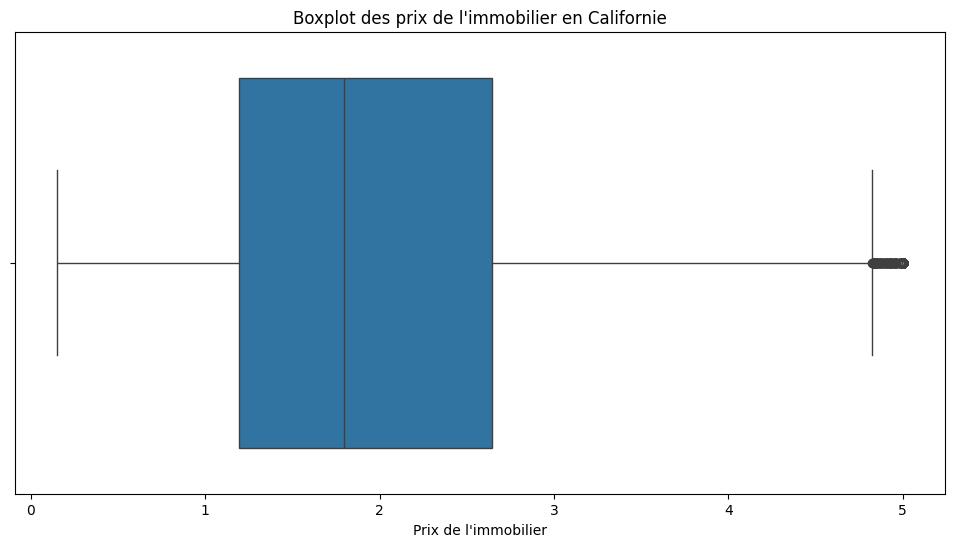

In [11]:
#Visualiser les outliers en utilisant un boxplot avec Seaborn
plt.figure(figsize=(12,6))
sns.boxplot(data=data, x='PRICE')
plt.xlabel("Prix de l'immobilier")
plt.title("Boxplot des prix de l'immobilier en Californie")
plt.show()

# 3. Identification des outliers univariées

**3.1 Identification des outliers IQR**

La méthode de l'IQR est une approche courante pour identifier les valeurs aberrantes dans des données univariées. Elle utilise l'écart interquartile pour définir une plage de valeurs plausibles et identifie les observations qui sont en dehors de cette plage.

**3.1.1 Définition**

L'IQR est défini comme la différence entre le troisième quartile (Q3) et le premier quartile (Q1) de la distribution des données. Les bornes inférieure et supérieure de la plage plausible sont définies comme suit :

- Limite inférieure : Q1 - 1,5 x IQR
- Limite supérieure : Q3 + 1,5 x IQR

Les observations en dehors de ces bornes sont considérées comme des valeurs aberrantes.

**3.1.2 Avantages**

La méthode de l'IQR est relativement simple à comprendre et à implémenter. Elle est également assez robuste aux valeurs aberrantes, car elle utilise la médiane et l'écart interquartile pour calculer les bornes plausibles.

**3.1.3 Inconvénients**

La méthode de l'IQR peut ne pas fonctionner correctement dans certaines distributions non symétriques, car elle suppose une distribution normale ou presque normale des données. Elle peut également ne pas fonctionner correctement si les données contiennent de nombreux points de données aberrants.

In [12]:
# Identification des données aberrantes - IQR
# Fonction pour détecter les outliers en utilisant l'IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

# Trouver les outliers pour la colonne 'PRICE'
outliers = detect_outliers_iqr(data, 'PRICE')

# Afficher les outliers
print("Outliers détectés:")
print(outliers)

Outliers détectés:
        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
89      1.2434      52.0  2.929412   0.917647       396.0  4.658824     37.80   
140     6.3624      30.0  5.615385   0.730769       126.0  2.423077     37.81   
459     1.1696      52.0  2.436000   0.944000      1349.0  5.396000     37.87   
489     3.0417      48.0  4.690632   1.126362      1656.0  3.607843     37.86   
493     7.8521      52.0  7.794393   1.051402       517.0  2.415888     37.86   
...        ...       ...       ...        ...         ...       ...       ...   
20422   5.1457      35.0  6.958333   1.217593       576.0  2.666667     34.14   
20426  10.0472      11.0  9.890756   1.159664       415.0  3.487395     34.18   
20427   8.6499       4.0  7.236059   1.032528      5495.0  2.553439     34.19   
20436  12.5420      10.0  9.873315   1.102426      1179.0  3.177898     34.21   
20443   3.3438      50.0  5.342857   0.942857       130.0  3.714286     34.27   

       L

**3.2 Identification des outliers avec Z-score**

**3.3 Méthode du z-score**

La méthode du z-score est une autre approche courante pour identifier les valeurs aberrantes dans des données univariées. Elle utilise l'écart à la moyenne pour définir une plage de valeurs plausibles et identifie les observations qui sont en dehors de cette plage.

**3.3.1 Définition**

Le z-score est défini comme la différence entre une observation et la moyenne de la distribution des données, divisée par l'écart-type de la distribution :

z = (x - μ) / σ

Les bornes inférieure et supérieure de la plage plausible sont définies comme suit :

- Limite inférieure : μ - 3 x σ
- Limite supérieure : μ + 3 x σ

Les observations en dehors de ces bornes sont considérées comme des valeurs aberrantes.

**3.3.2 Avantages**

La méthode du z-score est également relativement simple à comprendre et à implémenter. Elle est également assez robuste aux valeurs aberrantes, car elle utilise la moyenne et l'écart-type pour calculer les bornes plausibles.

**3.3.3 Inconvénients**

Comme pour la méthode de l'IQR, la méthode du z-score peut ne pas fonctionner correctement dans certaines distributions non symétriques. Elle peut également ne pas fonctionner correctement si les données contiennent de nombreux points de données aberrants.

In [13]:
# Identification des données aberrantes - Z-score
# Fonction pour détecter les outliers en utilisant le z-score
def detect_outliers_zscore(data, column, threshold=2):
    z_scores = (data[column] - data[column].mean()) / data[column].std()
    return data[np.abs(z_scores) > threshold]

# Trouver les outliers pour la colonne 'PRICE'
outliers = detect_outliers_zscore(data, 'PRICE')

# Afficher les outliers
print("Outliers détectés:")
print(outliers)

Outliers détectés:
        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0       8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
89      1.2434      52.0  2.929412   0.917647       396.0  4.658824     37.80   
140     6.3624      30.0  5.615385   0.730769       126.0  2.423077     37.81   
459     1.1696      52.0  2.436000   0.944000      1349.0  5.396000     37.87   
489     3.0417      48.0  4.690632   1.126362      1656.0  3.607843     37.86   
...        ...       ...       ...        ...         ...       ...       ...   
20422   5.1457      35.0  6.958333   1.217593       576.0  2.666667     34.14   
20426  10.0472      11.0  9.890756   1.159664       415.0  3.487395     34.18   
20427   8.6499       4.0  7.236059   1.032528      5495.0  2.553439     34.19   
20436  12.5420      10.0  9.873315   1.102426      1179.0  3.177898     34.21   
20443   3.3438      50.0  5.342857   0.942857       130.0  3.714286     34.27   

       L

# 5 Identification des outliers avec des approches univariés

**5.1 Analyse graphique**

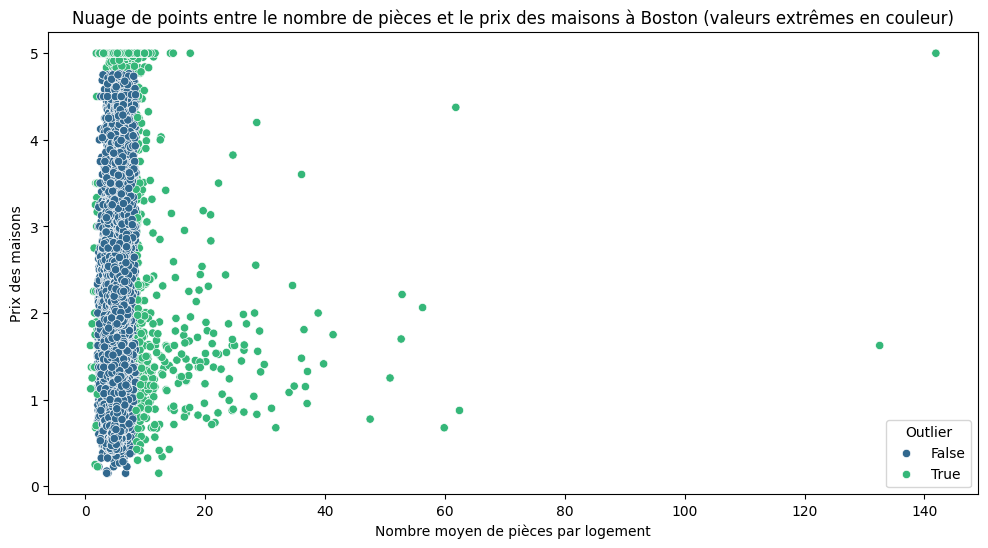

In [14]:
# Détecter les outliers pour les colonnes 'RM' et 'PRICE'
outliers_AveRooms= detect_outliers_iqr(data, 'AveRooms')
outliers_price = detect_outliers_iqr(data, 'PRICE')

# Ajouter une colonne pour indiquer si la valeur est extrême
data['Outlier'] = False
data.loc[outliers_AveRooms.index, 'Outlier'] = True
data.loc[outliers_price.index, 'Outlier'] = True

# Créer un nuage de points (scatter plot) avec Seaborn en mettant en évidence les valeurs extrêmes
plt.figure(figsize=(12, 6))
sns.scatterplot(data=data, x='AveRooms', y='PRICE', hue='Outlier', palette='viridis')
plt.xlabel('Nombre moyen de pièces par logement')
plt.ylabel('Prix des maisons')
plt.title("Nuage de points qui montre la relation entre taille des logements et prix")
plt.show()

# **5.2 Isolation Forest**

L'Isolation Forest est une méthode d'apprentissage automatique non supervisée pour identifier les valeurs aberrantes dans des données univariées et multivariées. Elle fonctionne en construisant plusieurs arbres de décision aléatoires et en calculant un score d'anomalie pour chaque observation en fonction de la profondeur moyenne à laquelle elle est isolée des autres observations.

**5.2.1 Définition**

L'Isolation Forest est basée sur l'idée que les valeurs aberrantes sont plus faciles à isoler que les valeurs normales. Elle construit plusieurs arbres de décision aléatoires et divise les données en sous-ensembles aléatoires à chaque nœud. L'algorithme isole les observations en fonction de la profondeur moyenne à laquelle elles sont isolées par rapport aux autres observations. Les observations qui sont isolées plus rapidement que la moyenne sont considérées comme des valeurs aberrantes.

**5.2.2 Avantages**

L'Isolation Forest est capable de détecter les valeurs aberrantes dans des données univariées et multivariées. Elle fonctionne également bien avec des distributions non symétriques et est assez robuste aux valeurs aberrantes.

**5.2.3 Inconvénients**

L'Isolation Forest peut être sensible aux paramètres tels que le nombre d'arbres et la taille des sous-échantillons. De plus, elle peut parfois être difficile à interpréter, en particulier pour les données multivariées.

In [15]:
from sklearn.ensemble import IsolationForest

# Appliquer l'Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
outlier_labels = iso_forest.fit_predict(data)

# Ajouter les labels d'anomalie au DataFrame
data['Outlier'] = outlier_labels

# Afficher les outliers
outliers = data[data['Outlier'] == -1]
print("Outliers détectés:")
print(outliers)

Outliers détectés:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
57     0.8172      52.0  6.102459   1.372951       728.0  2.983607     37.82   
59     2.5625       2.0  2.771930   0.754386        94.0  1.649123     37.82   
62     0.9011      50.0  6.229508   1.557377       377.0  3.090164     37.81   
63     1.1910      52.0  7.698113   1.490566       521.0  3.276730     37.81   
67     2.6094      52.0  6.986395   1.659864       492.0  3.346939     37.80   
...       ...       ...       ...        ...         ...       ...       ...   
20487  7.9013       5.0  8.319293   1.120924      2440.0  3.315217     34.30   
20527  1.4653       7.0  3.525794   1.017857      4479.0  8.886905     38.54   
20530  3.1371      11.0  5.070223   1.015530      7984.0  2.695476     38.57   
20563  3.1250       9.0  5.148007   1.119593      6837.0  2.899491     38.67   
20629  2.0943      28.0  5.519802   1.020902      6912.0  3.801980     39.12   

       Longitude  PR


Type de valeur aberrante	Solutions pour les traiter
Erreur	1. Correction de l'erreur si possible (ex. erreurs de saisie)
| | 2. Suppression de l'observation si la correction n'est pas possible et si l'erreur est clairement une anomalie | | 3. Remplacer par une valeur manquante et imputer avec les techniques d'imputation | | | | Extrême | 1. Transformation des données (ex. logarithmique, racine carrée) pour réduire l'impact des valeurs extrêmes | | | 2. Winsorisation : remplacer les valeurs extrêmes par des percentiles spécifiques (ex. 1er et 99e percentiles) | |
| | 3. Utiliser des modèles d'apprentissage automatique robustes aux valeurs extrêmes (ex. modèles basés sur les rangs) | | | 4. Discrétiser la variable | | | 5. Faire le modèle avec et sans les valeurs extrêmes et analyser l'impact |